In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

import scarf
from scarf.plotting import CellField, StudyDesign

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Choose a local folder for reusable input files.
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
# Create the local folder if it does not already exist.
dataset_directory.mkdir(parents=True, exist_ok=True)
# Name the local H5AD download.
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"
# Name the reusable converted count store.
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"

In [2]:
# Reuse completed local work when it is already present.
if not h5ad_path.exists():
    # Use a temporary filename until the download finishes.
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    # Download the complete input file to the temporary filename.
    urlretrieve(
        "https://datasets.cellxgene.cziscience.com/3b751975-34bb-409a-a9b7-98380f0450ea.h5ad",
        partial_path,
    )
    # Move the completed file or store to its reusable path.
    partial_path.replace(h5ad_path)

# Inspect the available count matrix before conversion.
inspection = scarf.inspect_h5ad(str(h5ad_path))
# Verify that the count matrix is stored at raw/X.
assert inspection.matrixKey == "raw/X"
# Verify that the matrix contains integer-like counts.
assert inspection.integerLike is True
# Verify the published cell and gene counts.
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
# Show the selected matrix and its cell and gene counts.
inspection.matrixKey, inspection.nCells, inspection.nFeatures

('raw/X', 108717, 21648)

In [3]:
# Reuse completed local work when it is already present.
if not source_store.exists():
    # Stage conversion in a temporary folder before publishing the completed store.
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        # Convert into a temporary store until every write succeeds.
        staged_store = Path(conversion_directory) / source_store.name
        # Read the count matrix and its cell and feature identifiers.
        reader = scarf.H5adReader.from_inspect(inspection)
        # Ensure the input reader is closed even if conversion fails.
        try:
            # Write the prepared counts and metadata to the new store.
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                assay_name="RNA",
                nthreads=4,
                mem_budget="6G",
            ).dump()
        finally:
            # Close the H5AD reader after conversion.
            reader.h5.close()
        # Move the completed file or store to its reusable path.
        staged_store.replace(source_store)

In [4]:
# Open the source without dropping cells before selecting the cohort.
source = scarf.DataStore(
    str(source_store), default_assay="RNA", min_features_per_cell=0, nthreads=4
)
# Check that initialization retained all published cells.
assert source.cells.N == 108_717

# Check the initialized count matrix dimensions.
{"cells": source.cells.N, "genes": source.RNA.feats.N}

{'cells': 108717, 'genes': 21648}

In [5]:
# Keep new analysis results in a temporary working folder.
analysis_directory = TemporaryDirectory()
# Open the datastore for the following analysis.
ds = scarf.mount_datastore(
    str(source_store),
    at=str(Path(analysis_directory.name) / "condition_analysis.zarr"),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
# Check that mounting preserved the source dimensions.
{
    "same cell count": ds.cells.N == source.cells.N,
    "same gene count": ds.RNA.feats.N == source.RNA.feats.N,
}

{'same cell count': True, 'same gene count': True}

In [6]:
# Keep a consistent order for control and rheumatoid arthritis.
GROUPS = ["normal", "rheumatoid arthritis"]
# Read the published fine cell-type labels.
fine_annotation = np.asarray(ds.cells.fetch_all("fine_annot"), dtype=object)
# Read the matched-pair identifier for each cell.
pair_index = np.asarray(ds.cells.fetch_all("pair_index_CW"), dtype=float)
# Keep gamma-delta T cells with a recorded matched pair.
matched_gamma_delta = np.isfinite(pair_index) & (fine_annotation == "yd T cells")
# Save the values in cell metadata using the stated selection.
ds.cells.insert("matched_yd_t_cells", matched_gamma_delta, overwrite=True)
# Freeze the selected cells for both the statistical test and plot.
cells = ds.snapshot_cell_selection("matched_yd_t_cells")
# Check how many cells were retained for the paired analysis.
{"selected cells": int(matched_gamma_delta.sum()), "total cells": ds.cells.N}

{'selected cells': 1386, 'total cells': 108717}

In [7]:
# Read the donor identity for each cell.
donor_id = np.asarray(ds.cells.fetch_all("donor_id"), dtype=object)
# Read each cell's biological condition.
disease = np.asarray(ds.cells.fetch_all("disease"), dtype=object)
# Reduce the selected metadata to one row per donor and pair.
donor_design = pd.DataFrame(
    {
        "donor_id": donor_id[matched_gamma_delta],
        "disease": disease[matched_gamma_delta],
        "pair_index_CW": pair_index[matched_gamma_delta],
    }
).drop_duplicates()
# Check the selected gamma-delta T-cell count.
assert int(matched_gamma_delta.sum()) == 1_386
# Require one design row per selected donor.
assert len(donor_design) == donor_design["donor_id"].nunique() == 36
# Require the expected 18 matched pairs.
assert donor_design["pair_index_CW"].nunique() == 18
# Require both comparison conditions in the selected design.
assert set(donor_design["disease"]) == set(GROUPS)
# Inspect the first four donor pairs and their disease labels.
donor_design.sort_values(["pair_index_CW", "disease"]).head(8)

,donor_id,disease,pair_index_CW
83,Control01_1_A_M,normal,1.0
15,RA01_1_A_M,rheumatoid arthritis,1.0
102,Control03_1_C_F,normal,3.0
68,RA03_1_C_F,rheumatoid arthritis,3.0
36,Control04_1_C_F,normal,4.0
476,RA04_1_C_F,rheumatoid arthritis,4.0
171,Control05_1_C_M,normal,5.0
65,RA05_1_C_M,rheumatoid arthritis,5.0


In [8]:
# Count donors and conditions within each matched pair.
pair_balance = donor_design.groupby("pair_index_CW", observed=True).agg(
    donors=("donor_id", "nunique"), conditions=("disease", "nunique")
)
# Require two donors in every matched pair.
assert pair_balance["donors"].eq(2).all()
# Require one donor from each condition in every pair.
assert pair_balance["conditions"].eq(2).all()
# Count the biological replicates in each condition.
donor_design.groupby("disease", observed=True).size().rename("donors")

disease
normal                  18
rheumatoid arthritis    18
Name: donors, dtype: int64

In [9]:
# Choose the six genes for this exploratory comparison.
panel = ["IFNG", "IFIT2", "TNF", "GZMA", "ISG15", "S100A4"]
# Use disease metadata to define the comparison groups.
condition = CellField("disease")
# Declare the donor, condition, and matched-pair columns.
design = StudyDesign(
    sample_by="donor_id", condition_by="disease", pair_by="pair_index_CW"
)

In [10]:
# Compare paired donor means with the Wilcoxon signed-rank test.
paired_result = ds.run_statistical_testing(
    panel,
    condition,
    cell_selection=cells,
    groups=GROUPS,
    study_design=design,
    test="wilcoxon",
)

In [11]:
# Combine the per-gene tests into one results table.
panel_table = pd.concat(
    {gene: paired_result.tables[gene] for gene in panel}, names=["gene"]
).reset_index(level="gene")
# Inspect pair counts and adjusted p-values for the six genes.
panel_table[["gene", "n_pairs", "statistic", "p_value", "p_value_adjusted"]]

,gene,n_pairs,statistic,p_value,p_value_adjusted
0,IFNG,18,39.0,1.000000,1.0000
0,IFIT2,18,26.0,0.878482,1.0000
0,TNF,18,57.0,0.864705,1.0000
0,GZMA,18,63.0,0.346550,0.6931
0,ISG15,18,13.0,0.139414,0.6931
0,S100A4,18,35.0,0.271948,0.6931


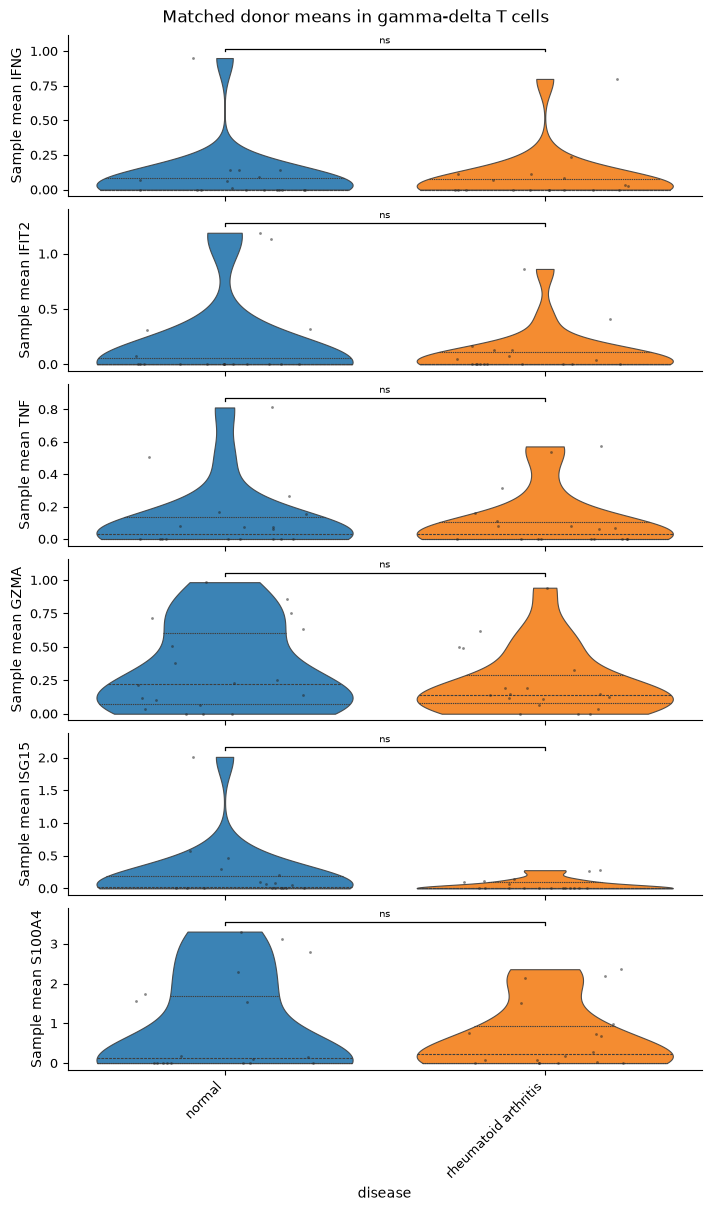

In [12]:
# Compare distributions within the stated groups.
ds.plots.distribution(
    panel,
    grouping=condition,
    cell_selection=cells,
    groups=GROUPS,
    study_design=design,
    kind="stacked_violin",
    figsize=(7, 12),
    point_size=2.0,
    point_alpha=0.55,
    share_y=False,
    stats_results=paired_result,
    stats_show_p=False,
    title="Matched donor means in gamma-delta T cells",
)